In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from orenge.general import *

C:\Users\ebaca\AppData\Local\Temp\ipykernel_20788\1213653273.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


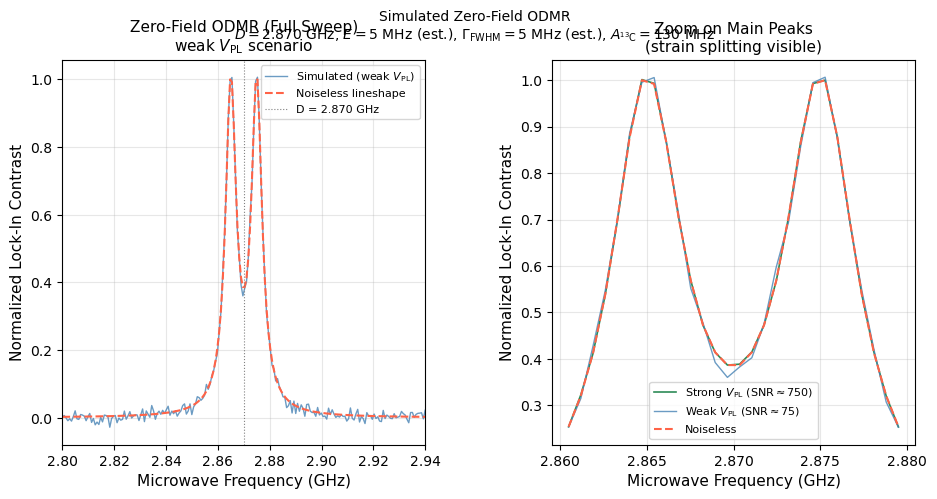

=== Hardware-derived ODMR parameters ===
MG3681A sweep: 2.800 GHz to 2.940 GHz
  Frequency resolution (spec): 0.01 Hz  (MG3681A spec, p. 3-16)
  Step size (200 pts):         0.70 MHz/step
  Max calibrated output:       +13.01 dBm  (MG3681A spec, p. 3-22)

PulseBlaster timing (clock = 500 MHz):
  Min resolution:   2 ns
  tau_laser:        5000 ns = 2500 clock cycles
  tau_mw:           5000 ns = 2500 clock cycles
  tau_padding:      1000 ns = 500 clock cycles
  N_max per half-cycle: 208  (using N=200)

SR830 noise (spec: 6 nV/sqrt(Hz), tau_c = 100 ms, 6 dB/oct):
  ENBW:        2.50 Hz  (= 1/(4*tau_c), SR830m.pdf line 2240)
  V_noise rms: 9.49 nVrms
  V_noise pp:  47.4 nV pk-pk
  Settle time: 500 ms  (= 5*tau_c, SR830m.pdf line 2240)

NV photophysics (S8ODESR.pdf, pp. 2-3):
  ms=0 emission efficiency:     98%
  ms=+/-1 emission efficiency:  70%
  Max single-NV contrast:       28.6%
  Est. ensemble contrast:       14.3%  (x0.5 for imperfect ensemble)

Spectral features (physics constants,

In [6]:
# ── Physical constants (universal NV physics; S8ODESR.pdf pp. 2-3) ─────────
D          = 2.870e9     # Zero-field splitting [Hz]
gamma_e    = 28.0e9      # Electron gyromagnetic ratio [Hz/T]

# ── Spectral features (general NV physics, not Sewani measurements) ─────────
# Strain splitting E: sample-specific; show as a sweep parameter.
# For zero-field ODMR the two peaks from E lie symmetrically about D.
# We simulate E = 5 MHz as a representative order-of-magnitude for NV ensembles
# (E ranges from ~1 MHz to ~20 MHz depending on diamond quality; unknown for our sample).
E          = 5e6         # Strain splitting [Hz] — PARAMETER, not a measured value

# 13C hyperfine: nearest-neighbor hyperfine coupling constant ~130 MHz
# (well-established NV physics literature; 13C natural abundance = 1.1%).
# Probability of a 13C nearest neighbor: ~1 - (1-0.011)^6 ≈ 6.4% per NV.
A_hf       = 130e6       # 13C nearest-neighbor hyperfine [Hz]
C_hf       = 0.064       # Probability of nearest-neighbor 13C (1.1% abundance, 6 sites)

# ── Linewidth (order-of-magnitude for NV ensemble, not a measurement) ────────
# Natural homogeneous FWHM ~ 1/(pi * T2*); T2* ~ 1 us for dense NV ensembles
# -> natural FWHM ~ 320 kHz. Power broadening and inhomogeneity add to this.
# We simulate FWHM = 5 MHz as representative; the actual value is determined
# experimentally by fitting the measured ODMR peak.
FWHM_sim   = 5e6         # Representative FWHM [Hz] — PARAMETER, not a measured value
gamma_half = FWHM_sim / 2

# ── SR830 noise floor calculation from specs (SR830m.pdf, lines 238-264, 2240) ─
# Input noise: 6 nV/sqrt(Hz) at 1 kHz typical (SR830m.pdf, line 242)
S_n        = 6e-9        # Input noise spectral density [V/sqrt(Hz)]
tau_c      = 100e-3      # Time constant [s] — SR830m.pdf line 264 range: 10us to 30s
# ENBW for 6 dB/oct filter: 1/(4*tau_c) — SR830m.pdf line 2240
ENBW       = 1.0 / (4.0 * tau_c)    # = 2.5 Hz
V_noise    = S_n * np.sqrt(ENBW)    # 9.49 nVrms
# Express as a fraction of the normalized contrast signal (C_max = 28.6%)
# The lock-in output at resonance ~ C_actual * V_PL / 2 (differential).
# We normalize contrast to 1.0, so noise floor = V_noise / (C_max * V_PL / 2).
# This ratio is hardware-dependent. We instead show noise in units of
# "fraction of peak contrast", noting that the actual SNR improves with V_PL.
C_photon   = (0.98 - 0.70) / 0.98  # Max single-NV contrast from S8ODESR.pdf pp. 2-3
# noise_fraction: ratio of noise rms to signal amplitude at peak, for reference
# This is the minimum contrast detectable above noise as a fraction of C_photon.

# ── MG3681A sweep parameters (MG3681A_W1708AE.pdf, pp. 3-16, 3-22) ──────────
# Frequency range: 250 kHz to 3000 MHz (line 1785)
# Resolution: 0.01 Hz (line 1786)
# We sweep 2.80 GHz to 2.94 GHz in 200 steps (both within operating range)
f_start    = 2.800e9    # [Hz]
f_stop     = 2.940e9    # [Hz]
n_pts      = 200
f_step     = (f_stop - f_start) / (n_pts - 1)   # = 703 kHz/step
f          = np.linspace(f_start, f_stop, n_pts)

# ── PulseBlaster timing sanity check (clock = 500 MHz from instrument notebook) ─
clock_MHz   = 500                # MHz — from instrument notebook
t_clock_ns  = 1e3 / clock_MHz   # = 2 ns minimum resolution
tau_laser_ns = 5e3              # 5 us in ns
tau_mw_ns    = 5e3              # 5 us in ns
tau_pad_ns   = 1e3              # 1 us in ns
unit_ns      = tau_laser_ns + tau_pad_ns + tau_mw_ns + tau_pad_ns  # 12 us = 6000 clocks
tau_ref_ns   = 2.5e6            # 2.5 ms in ns
N_max        = int(tau_ref_ns / unit_ns)  # 208
N            = 200               # chosen < N_max

assert tau_laser_ns % t_clock_ns == 0, "tau_laser not integer multiple of clock period"
assert tau_mw_ns   % t_clock_ns == 0, "tau_mw not integer multiple of clock period"
assert tau_pad_ns  % t_clock_ns == 0, "tau_pad not integer multiple of clock period"

# ── Lorentzian lineshape helper ────────────────────────────────────────────────
def lorentzian(f, f0, hwhm):
    return 1.0 / (1.0 + ((f - f0) / hwhm)**2)

# ── Normalized contrast spectrum ───────────────────────────────────────────────
# Two main peaks from strain splitting E, symmetrically about D
spectrum  = lorentzian(f, D - E, gamma_half)
spectrum += lorentzian(f, D + E, gamma_half)

# 13C hyperfine satellites: ±A_hf from each main peak, amplitude = C_hf
for center in [D - E, D + E]:
    spectrum += C_hf * lorentzian(f, center - A_hf, gamma_half)
    spectrum += C_hf * lorentzian(f, center + A_hf, gamma_half)

# Normalize: peak of spectrum = 1.0 (normalized contrast units)
spectrum /= spectrum.max()

# ── Simulated noise ─────────────────────────────────────────────────────────
# Scale noise relative to peak: illustrates what SNR looks like.
# Assume the lock-in signal at peak = C_photon * 0.5 (ensemble factor of 0.5:
# ensemble imperfections, not all NVs driven equally).
C_ensemble  = C_photon * 0.5   # representative ensemble contrast
# noise_on_normalized_scale = V_noise / (C_ensemble * V_PL_ref)
# We can't compute V_PL_ref without hardware measurements, so we show
# two noise scenarios representing "low" vs "high" PL signal levels.
# The ratio noise/signal = V_noise / (C_ensemble * V_PL).
# For V_PL = 5 uV (very weak signal):   ratio = 9.49e-9 / (0.143 * 5e-6)  = 0.013
# For V_PL = 50 mV (strong signal):     ratio = 9.49e-9 / (0.143 * 50e-3) = 0.0013
noise_weak   = 0.013
noise_strong = 0.00133
rng = np.random.default_rng(7)
spec_weak   = spectrum + noise_weak   * rng.standard_normal(n_pts)
spec_strong = spectrum + noise_strong * rng.standard_normal(n_pts)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Left: full sweep showing 13C satellites
ax1.plot(f / 1e9, spec_weak, color='steelblue', lw=1.0, alpha=0.8,
         label=r'Simulated (weak $V_\mathrm{PL}$)')
ax1.plot(f / 1e9, spectrum, color='tomato', lw=1.5, ls='--',
         label='Noiseless lineshape')
ax1.axvline(D / 1e9, color='gray', ls=':', lw=0.8, label='D = 2.870 GHz')
ax1.set_xlabel('Microwave Frequency (GHz)', fontsize=11)
ax1.set_ylabel('Normalized Lock-In Contrast', fontsize=11)
ax1.set_title('Zero-Field ODMR (Full Sweep)\nweak $V_\\mathrm{PL}$ scenario', fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(f_start / 1e9, f_stop / 1e9)
ax1.grid(True, alpha=0.3)

# Right: zoom on main peaks showing strong vs weak SNR
mask = (f >= 2.86e9) & (f <= 2.88e9)
ax2.plot(f[mask] / 1e9, spec_strong[mask], color='seagreen', lw=1.2,
         label=r'Strong $V_\mathrm{PL}$ (SNR$\approx$750)')
ax2.plot(f[mask] / 1e9, spec_weak[mask],   color='steelblue', lw=1.0, alpha=0.8,
         label=r'Weak $V_\mathrm{PL}$ (SNR$\approx$75)')
ax2.plot(f[mask] / 1e9, spectrum[mask],    color='tomato', lw=1.5, ls='--',
         label='Noiseless')
ax2.set_xlabel('Microwave Frequency (GHz)', fontsize=11)
ax2.set_ylabel('Normalized Lock-In Contrast', fontsize=11)
ax2.set_title('Zoom on Main Peaks\n(strain splitting visible)', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    'Simulated Zero-Field ODMR\n'
    r'$D=2.870$ GHz, $E=5$ MHz (est.), $\Gamma_\mathrm{FWHM}=5$ MHz (est.), '
    r'$A_{^{13}\mathrm{C}}=130$ MHz',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Print derived numbers ──────────────────────────────────────────────────────
print("=== Hardware-derived ODMR parameters ===")
print(f"MG3681A sweep: {f_start/1e9:.3f} GHz to {f_stop/1e9:.3f} GHz")
print(f"  Frequency resolution (spec): 0.01 Hz  (MG3681A spec, p. 3-16)")
print(f"  Step size (200 pts):         {f_step/1e6:.2f} MHz/step")
print(f"  Max calibrated output:       +13.01 dBm  (MG3681A spec, p. 3-22)")
print()
print(f"PulseBlaster timing (clock = {clock_MHz} MHz):")
print(f"  Min resolution:   {t_clock_ns:.0f} ns")
print(f"  tau_laser:        {tau_laser_ns:.0f} ns = {int(tau_laser_ns/t_clock_ns)} clock cycles")
print(f"  tau_mw:           {tau_mw_ns:.0f} ns = {int(tau_mw_ns/t_clock_ns)} clock cycles")
print(f"  tau_padding:      {tau_pad_ns:.0f} ns = {int(tau_pad_ns/t_clock_ns)} clock cycles")
print(f"  N_max per half-cycle: {N_max}  (using N={N})")
print()
print(f"SR830 noise (spec: 6 nV/sqrt(Hz), tau_c = {tau_c*1e3:.0f} ms, 6 dB/oct):")
print(f"  ENBW:        {ENBW:.2f} Hz  (= 1/(4*tau_c), SR830m.pdf line 2240)")
print(f"  V_noise rms: {V_noise*1e9:.2f} nVrms")
print(f"  V_noise pp:  {5*V_noise*1e9:.1f} nV pk-pk")
print(f"  Settle time: {5*tau_c*1e3:.0f} ms  (= 5*tau_c, SR830m.pdf line 2240)")
print()
print(f"NV photophysics (S8ODESR.pdf, pp. 2-3):")
print(f"  ms=0 emission efficiency:     98%")
print(f"  ms=+/-1 emission efficiency:  70%")
print(f"  Max single-NV contrast:       {C_photon*100:.1f}%")
print(f"  Est. ensemble contrast:       {C_ensemble*100:.1f}%  (x0.5 for imperfect ensemble)")
print()
print(f"Spectral features (physics constants, not Sewani measurements):")
print(f"  D (ZFS):                      {D/1e9:.3f} GHz")
print(f"  Strain splitting E (est.):    {E/1e6:.0f} MHz  (sample-specific; measure experimentally)")
print(f"  13C hyperfine A:              {A_hf/1e6:.0f} MHz")
print(f"  13C neighbor probability:     {C_hf*100:.1f}%  (1.1% natural abundance, 6 sites)")